In [1]:
import pandas as pd
import numpy as np
import glob
import os
from tqdm import tqdm

In [3]:
!unzip -q league_events_data.zip -d /content/data

In [4]:
DATA_PATH = '/content/data/league_events_data'

In [46]:
SHOT_TYPES = ['Goal', 'SavedShot', 'MissedShot', 'BlockedShot', 'ShotOnPost']

def backfill_assist_context(df_match):
    """
    Assist info lives on the preceding PASS row, not the shot row.
    Looks back up to 5 events, finds the most recent same-team pass,
    and copies its flags onto the shot row.
    Enforces mutual exclusivity: corner > freekick > cross > throughball
    """
    df = df_match.copy()
    shot_indices = df[df['type'].isin(SHOT_TYPES)].index.tolist()

    for idx in shot_indices:
        shot_team = df.loc[idx, 'team']
        window_start = max(df.index[0], idx - 5)
        preceding = df.loc[window_start:idx - 1]

        same_team_passes = preceding[
            (preceding['type'] == 'Pass') &
            (preceding['team'] == shot_team)
        ]

        if same_team_passes.empty:
            continue

        assist_row = same_team_passes.iloc[-1]

        is_cross       = bool(assist_row.get('is_cross', False))
        is_corner      = bool(assist_row.get('is_corner', False))
        is_freekick    = bool(assist_row.get('is_freekick', False))
        is_throughball = bool(assist_row.get('is_through_ball', False))

        # Corner takes priority over cross
        # (a corner IS a cross but more specific)
        if is_corner:
            is_cross = False

        # Assign with mutual exclusivity — only one flag True per shot
        df.loc[idx, 'is_assist_throughball'] = is_throughball
        df.loc[idx, 'is_assist_freekick']    = is_freekick    and not is_throughball
        df.loc[idx, 'is_assist_corner']      = is_corner      and not is_freekick and not is_throughball
        df.loc[idx, 'is_assist_cross']       = is_cross       and not is_corner   and not is_freekick and not is_throughball

    return df


def extract_and_clean(root_path):
    all_shots = []
    file_paths = glob.glob(os.path.join(root_path, "**/*.csv"), recursive=True)
    print(f"Found {len(file_paths)} match files. Extracting shots...")

    for file in tqdm(file_paths):
        try:
            df = pd.read_csv(file)

            # Backfill BEFORE filtering — needs full event stream
            df = backfill_assist_context(df)

            shots = df[df['type'].isin(SHOT_TYPES)].copy()
            if shots.empty:
                continue

            if 'is_own_goal' in shots.columns:
                shots = shots[shots['is_own_goal'] != True]
            if 'is_penalty' in shots.columns:
                shots = shots[shots['is_penalty'] != True]

            shots = shots[shots['x'] >= 50]
            shots['is_goal'] = (shots['type'] == 'Goal').astype(int)

            all_shots.append(shots)

        except Exception as e:
            print(f"  Error in {file}: {e}")

    df_raw = pd.concat(all_shots, ignore_index=True)
    return df_raw


df_raw = extract_and_clean(DATA_PATH)
print(f"\nBase dataset: {df_raw.shape[0]:,} shots")
print(f"Goal rate:    {df_raw['is_goal'].mean():.3f} ({df_raw['is_goal'].sum():,} goals)")

# Verify mutual exclusivity of assist flags
shots_with_assist = df_raw[
    (df_raw['is_assist_cross'].astype(int) +
     df_raw['is_assist_corner'].astype(int) +
     df_raw['is_assist_freekick'].astype(int) +
     df_raw['is_assist_throughball'].astype(int)) > 1
]
print(f"\nShots with 2+ assist flags (should be 0): {len(shots_with_assist)}")

Found 1545 match files. Extracting shots...


100%|██████████| 1545/1545 [01:45<00:00, 14.66it/s]



Base dataset: 38,176 shots
Goal rate:    0.098 (3,746 goals)

Shots with 2+ assist flags (should be 0): 0


In [49]:
identifiers = ['matchName', 'team', 'playerName', 'minute', 'second']

features = [
    'x', 'y',
    'is_header', 'is_volley',
    'is_left_foot', 'is_right_foot',
    'is_fast_break', 'is_big_chance',
    'is_assist_throughball', 'is_assist_cross',
    'is_assist_corner', 'is_assist_freekick'
]

target = ['is_goal']

df_filtered = df_raw[identifiers + features + target].copy()

coord_cols = ['x', 'y']
binary_cols = [f for f in features if f not in coord_cols]
df_filtered[binary_cols] = df_filtered[binary_cols].fillna(0).astype(int)


def calculate_geometry(df):
    df['x_met'] = df['x'] * (105 / 100)
    df['y_met'] = df['y'] * (68 / 100)

    df['distance'] = np.sqrt((105 - df['x_met'])**2 + (34 - df['y_met'])**2)

    angle_to_post1 = np.arctan2(37.66 - df['y_met'], 105 - df['x_met'])
    angle_to_post2 = np.arctan2(30.34 - df['y_met'], 105 - df['x_met'])
    df['angle_deg'] = np.degrees(np.abs(angle_to_post1 - angle_to_post2))

    df['log_distance'] = np.log(df['distance'])

    # Clip to training distribution
    log_dist_p01 = df['log_distance'].quantile(0.01)
    log_dist_p99 = df['log_distance'].quantile(0.99)
    angle_p01    = df['angle_deg'].quantile(0.01)
    angle_p99    = df['angle_deg'].quantile(0.99)

    df['log_distance'] = df['log_distance'].clip(log_dist_p01, log_dist_p99)
    df['angle_deg']    = df['angle_deg'].clip(angle_p01, angle_p99)

    clip_values = {
        'log_dist_min' : round(log_dist_p01, 4),
        'log_dist_max' : round(log_dist_p99, 4),
        'angle_min'    : round(angle_p01, 4),
        'angle_max'    : round(angle_p99, 4)
    }

    df = df.drop(columns=['x', 'y', 'x_met', 'y_met', 'distance'])
    return df, clip_values


df_filtered, clip_values = calculate_geometry(df_filtered)

print(f"Shape: {df_filtered.shape}")
print(f"\nClip values (save these for inference):")
for k, v in clip_values.items():
    print(f"  {k}: {v}")

print(f"\nAssist flag totals:")
for col in ['is_assist_cross','is_assist_corner','is_assist_freekick','is_assist_throughball']:
    n = df_filtered[col].sum()
    print(f"  {col}: {n} ({n/len(df_filtered)*100:.1f}%)")

print(f"\nFeature columns:")
print([c for c in df_filtered.columns if c not in identifiers + ['is_goal']])

Shape: (38176, 18)

Clip values (save these for inference):
  log_dist_min: 1.3428
  log_dist_max: 3.5061
  angle_min: 9.1022
  angle_max: 86.5536

Assist flag totals:
  is_assist_cross: 6715 (17.6%)
  is_assist_corner: 3985 (10.4%)
  is_assist_freekick: 1501 (3.9%)
  is_assist_throughball: 1336 (3.5%)

Feature columns:
['is_header', 'is_volley', 'is_left_foot', 'is_right_foot', 'is_fast_break', 'is_big_chance', 'is_assist_throughball', 'is_assist_cross', 'is_assist_corner', 'is_assist_freekick', 'angle_deg', 'log_distance']


In [50]:
from sklearn.model_selection import train_test_split

train_features = [
    'log_distance',
    'angle_deg',
    'is_header', 'is_volley',
    'is_left_foot', 'is_right_foot',
    'is_fast_break', 'is_big_chance',
    'is_assist_throughball', 'is_assist_cross',
    'is_assist_corner', 'is_assist_freekick'
]

X = df_filtered[train_features]
y = df_filtered['is_goal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train):,}  ({y_train.sum():,} goals, {y_train.mean():.3f} rate)")
print(f"Testing samples  : {len(X_test):,}  ({y_test.sum():,} goals, {y_test.mean():.3f} rate)")

print(f"\nCorrelation — spatial features:")
print(X_train[['log_distance', 'angle_deg']].corr().round(3))

print(f"\nFeature count: {len(train_features)}")
print(train_features)

Training samples : 30,540  (2,997 goals, 0.098 rate)
Testing samples  : 7,636  (749 goals, 0.098 rate)

Correlation — spatial features:
              log_distance  angle_deg
log_distance         1.000     -0.901
angle_deg           -0.901      1.000

Feature count: 12
['log_distance', 'angle_deg', 'is_header', 'is_volley', 'is_left_foot', 'is_right_foot', 'is_fast_break', 'is_big_chance', 'is_assist_throughball', 'is_assist_cross', 'is_assist_corner', 'is_assist_freekick']


In [51]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# --- 1. Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("✓ Logistic Regression trained")

# --- 2. XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"✓ XGBoost trained — best iteration: {xgb_model.best_iteration}")

✓ Logistic Regression trained
✓ XGBoost trained — best iteration: 107


In [52]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

def evaluate_models(models, X, y):
    results = []
    actual_goal_rate = y.mean()

    for name, model in models.items():
        probs = model.predict_proba(X)[:, 1]

        auc   = roc_auc_score(y, probs)
        brier = brier_score_loss(y, probs)
        ll    = log_loss(y, probs)
        avg_xg = probs.mean()
        calibration_gap = abs(avg_xg - actual_goal_rate)

        results.append({
            'Model'           : name,
            'ROC AUC'         : round(auc, 4),
            'Brier Score'     : round(brier, 4),
            'Log Loss'        : round(ll, 4),
            'Avg xG'          : round(avg_xg, 4),
            'Calibration Gap' : round(calibration_gap, 4)
        })

    return pd.DataFrame(results)

model_dict = {
    'Logistic Regression' : lr_model,
    'XGBoost'             : xgb_model
}

print(f"Actual goal rate in test set: {y_test.mean():.4f}")
print()
report = evaluate_models(model_dict, X_test, y_test)
print(report.to_string(index=False))

Actual goal rate in test set: 0.0981

              Model  ROC AUC  Brier Score  Log Loss  Avg xG  Calibration Gap
Logistic Regression   0.7740       0.0780    0.2749  0.0980           0.0001
            XGBoost   0.7756       0.0774    0.2728  0.0981           0.0000


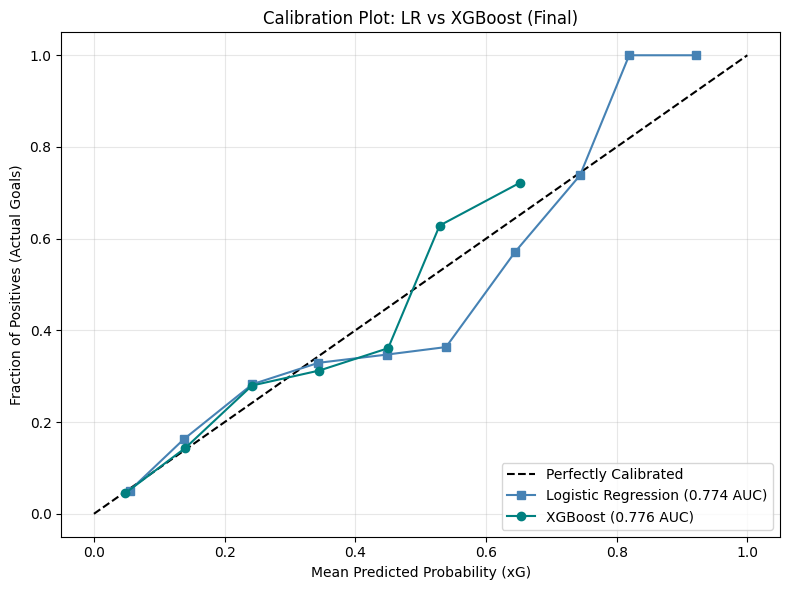

In [53]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

lr_probs  = lr_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

lr_y,  lr_x  = calibration_curve(y_test, lr_probs,  n_bins=10)
xgb_y, xgb_x = calibration_curve(y_test, xgb_probs, n_bins=10)

lr_auc  = roc_auc_score(y_test, lr_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.plot(lr_x,  lr_y,  's-', color='steelblue',
         label=f'Logistic Regression ({lr_auc:.3f} AUC)')
plt.plot(xgb_x, xgb_y, 'o-', color='teal',
         label=f'XGBoost ({xgb_auc:.3f} AUC)')

plt.xlabel('Mean Predicted Probability (xG)')
plt.ylabel('Fraction of Positives (Actual Goals)')
plt.title('Calibration Plot: LR vs XGBoost (Final)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

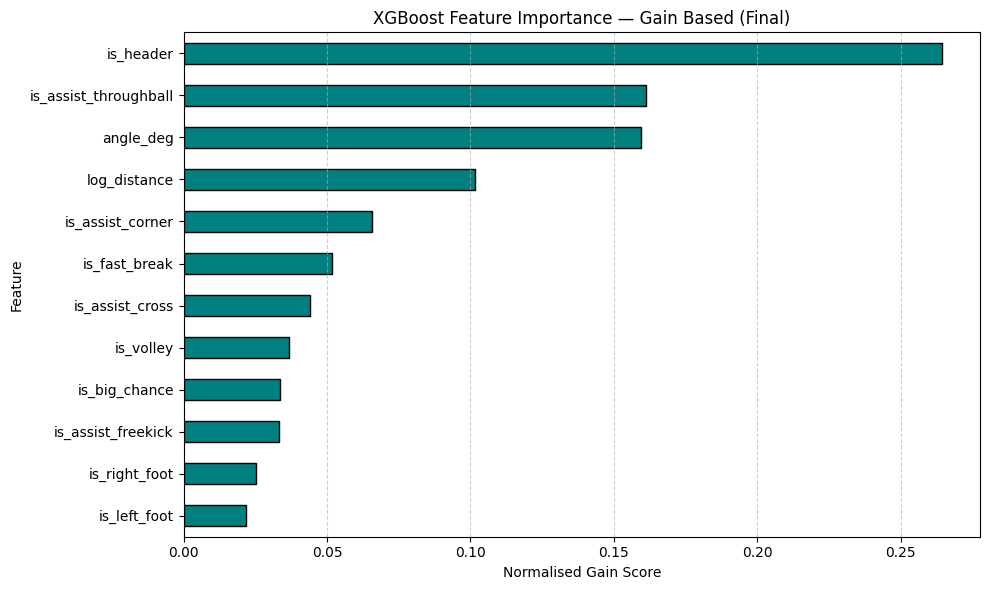


Feature importance rankings:
  is_header                 0.2644
  is_assist_throughball     0.1613
  angle_deg                 0.1596
  log_distance              0.1017
  is_assist_corner          0.0658
  is_fast_break             0.0519
  is_assist_cross           0.0442
  is_volley                 0.0369
  is_big_chance             0.0338
  is_assist_freekick        0.0332
  is_right_foot             0.0254
  is_left_foot              0.0219


In [54]:
import matplotlib.pyplot as plt

booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type='gain')

feature_map = {f'f{i}': name for i, name in enumerate(train_features)}
feat_importance = pd.Series({
    feature_map.get(k, k): v for k, v in gain_scores.items()
})

feat_importance = feat_importance / feat_importance.sum()
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='teal', edgecolor='black')
plt.title('XGBoost Feature Importance — Gain Based (Final)')
plt.xlabel('Normalised Gain Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nFeature importance rankings:")
for feat, score in feat_importance.sort_values(ascending=False).items():
    print(f"  {feat:<25} {score:.4f}")

In [60]:
import pickle

# --- Save XGBoost in native JSON format (version-independent) ---
xgb_model.save_model('xgb_xg_model.json')
print("✓ XGBoost model saved as JSON (version-independent)")

# --- Save features and clip values as pickle (these are just Python dicts/lists) ---
with open('xg_features.pkl', 'wb') as f:
    pickle.dump(train_features, f)
print("✓ Feature list saved")

with open('xg_clip_values.pkl', 'wb') as f:
    pickle.dump(clip_values, f)
print("✓ Clip values saved")

# --- Verify reload ---
import xgboost as xgb

xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model('xgb_xg_model.json')

with open('xg_features.pkl', 'rb') as f:
    features_loaded = pickle.load(f)

with open('xg_clip_values.pkl', 'rb') as f:
    clips_loaded = pickle.load(f)

test_probs = xgb_loaded.predict_proba(X_test)[:, 1]
test_auc   = roc_auc_score(y_test, test_probs)

print(f"\n--- Verification ---")
print(f"AUC after reload : {test_auc:.4f}  (should match 0.7756)")
print(f"Features         : {features_loaded}")
print(f"Clip values      : {clips_loaded}")

✓ XGBoost model saved as JSON (version-independent)
✓ Feature list saved
✓ Clip values saved

--- Verification ---
AUC after reload : 0.7756  (should match 0.7756)
Features         : ['log_distance', 'angle_deg', 'is_header', 'is_volley', 'is_left_foot', 'is_right_foot', 'is_fast_break', 'is_big_chance', 'is_assist_throughball', 'is_assist_cross', 'is_assist_corner', 'is_assist_freekick']
Clip values      : {'log_dist_min': np.float64(1.3428), 'log_dist_max': np.float64(3.5061), 'angle_min': np.float64(9.1022), 'angle_max': np.float64(86.5536)}


In [61]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb

# --- Load XGBoost from JSON (version-independent) ---
model = xgb.XGBClassifier()
model.load_model('xgb_xg_model.json')
print("✓ XGBoost model loaded from JSON")

# --- Load features and clip values ---
with open('xg_features.pkl', 'rb') as f:
    features = pickle.load(f)

with open('xg_clip_values.pkl', 'rb') as f:
    clips = pickle.load(f)

print("✓ Features and clip values loaded")
print(f"Features    : {features}")
print(f"Clip values : {clips}")

✓ XGBoost model loaded from JSON
✓ Features and clip values loaded
Features    : ['log_distance', 'angle_deg', 'is_header', 'is_volley', 'is_left_foot', 'is_right_foot', 'is_fast_break', 'is_big_chance', 'is_assist_throughball', 'is_assist_cross', 'is_assist_corner', 'is_assist_freekick']
Clip values : {'log_dist_min': np.float64(1.3428), 'log_dist_max': np.float64(3.5061), 'angle_min': np.float64(9.1022), 'angle_max': np.float64(86.5536)}


In [62]:
SHOT_TYPES = ['Goal', 'SavedShot', 'MissedShot', 'BlockedShot', 'ShotOnPost']

def backfill_assist_context(df_match):
    df = df_match.copy()
    shot_indices = df[df['type'].isin(SHOT_TYPES)].index.tolist()

    for idx in shot_indices:
        shot_team = df.loc[idx, 'team']
        window_start = max(df.index[0], idx - 5)
        preceding = df.loc[window_start:idx - 1]

        same_team_passes = preceding[
            (preceding['type'] == 'Pass') &
            (preceding['team'] == shot_team)
        ]

        if same_team_passes.empty:
            continue

        assist_row = same_team_passes.iloc[-1]

        is_cross       = bool(assist_row.get('is_cross', False))
        is_corner      = bool(assist_row.get('is_corner', False))
        is_freekick    = bool(assist_row.get('is_freekick', False))
        is_throughball = bool(assist_row.get('is_through_ball', False))

        if is_corner:
            is_cross = False

        df.loc[idx, 'is_assist_throughball'] = is_throughball
        df.loc[idx, 'is_assist_freekick']    = is_freekick    and not is_throughball
        df.loc[idx, 'is_assist_corner']      = is_corner      and not is_freekick and not is_throughball
        df.loc[idx, 'is_assist_cross']       = is_cross       and not is_corner   and not is_freekick and not is_throughball

    return df


def prepare_match_features(df_match, clips):
    df_match['x_met'] = df_match['x'] * (105 / 100)
    df_match['y_met'] = df_match['y'] * (68 / 100)

    df_match['distance'] = np.sqrt(
        (105 - df_match['x_met'])**2 + (34 - df_match['y_met'])**2
    )

    angle_to_post1 = np.arctan2(37.66 - df_match['y_met'], 105 - df_match['x_met'])
    angle_to_post2 = np.arctan2(30.34 - df_match['y_met'], 105 - df_match['x_met'])
    df_match['angle_deg'] = np.degrees(np.abs(angle_to_post1 - angle_to_post2))

    df_match['log_distance'] = np.log(df_match['distance'])

    df_match['log_distance'] = df_match['log_distance'].clip(
        clips['log_dist_min'], clips['log_dist_max']
    )
    df_match['angle_deg'] = df_match['angle_deg'].clip(
        clips['angle_min'], clips['angle_max']
    )

    binary_cols = [
        'is_header', 'is_volley', 'is_left_foot', 'is_right_foot',
        'is_fast_break', 'is_big_chance', 'is_assist_throughball',
        'is_assist_cross', 'is_assist_corner', 'is_assist_freekick'
    ]
    df_match[binary_cols] = df_match[binary_cols].fillna(0).astype(int)

    return df_match


def predict_match_xg(filepath, model, features, clips):
    df = pd.read_csv(filepath)

    # Backfill BEFORE filtering
    df = backfill_assist_context(df)

    # Filter to shots
    shots = df[df['type'].isin(SHOT_TYPES)].copy()

    # Exclusions
    if 'is_own_goal' in shots.columns:
        shots = shots[shots['is_own_goal'] != True]
    if 'is_penalty' in shots.columns:
        shots = shots[shots['is_penalty'] != True]
    shots = shots[shots['x'] >= 50]

    if shots.empty:
        print("No valid shots found in match file.")
        return pd.DataFrame()

    # Feature engineering
    shots = prepare_match_features(shots, clips)

    # Predict
    shots['xG'] = model.predict_proba(shots[features])[:, 1]

    return shots


# --- Run on Real Betis vs Real Madrid ---
match_file = 'whoscored_Real_Betis_vs_Real_Madrid_all_events.csv'
shots = predict_match_xg(match_file, model, features, clips)

# --- Results ---
print("=== CUMULATIVE xG BY TEAM ===")
team_xg = shots.groupby('team')['xG'].sum().round(3)
print(team_xg)

print(f"\n=== SHOT BREAKDOWN ===")
for team in shots['team'].unique():
    team_shots = shots[shots['team'] == team]
    print(f"\n{team}:")
    print(f"  Shots          : {len(team_shots)}")
    print(f"  Total xG       : {team_shots['xG'].sum():.3f}")
    print(f"  Avg xG/shot    : {team_shots['xG'].mean():.3f}")
    print(f"  Max xG         : {team_shots['xG'].max():.3f}")

print(f"\n=== ACTUAL RESULT ===")
print(f"  Real Betis  xG : 1.08 (actual)")
print(f"  Real Madrid xG : 1.19 (actual)")

print(f"\n=== SHOT BY SHOT ===")
shot_display = shots[['minute', 'playerName', 'team', 'type', 'xG']].sort_values('minute')
shot_display['xG'] = shot_display['xG'].round(3)
print(shot_display.to_string(index=False))

=== CUMULATIVE xG BY TEAM ===
team
Real Betis     1.488
Real Madrid    1.083
Name: xG, dtype: float32

=== SHOT BREAKDOWN ===

Real Madrid:
  Shots          : 12
  Total xG       : 1.083
  Avg xG/shot    : 0.090
  Max xG         : 0.202

Real Betis:
  Shots          : 19
  Total xG       : 1.488
  Avg xG/shot    : 0.078
  Max xG         : 0.249

=== ACTUAL RESULT ===
  Real Betis  xG : 1.08 (actual)
  Real Madrid xG : 1.19 (actual)

=== SHOT BY SHOT ===
 minute        playerName        team        type    xG
      7     Kylian Mbappé Real Madrid  MissedShot 0.076
     12     Kylian Mbappé Real Madrid  MissedShot 0.076
     16 Federico Valverde Real Madrid   SavedShot 0.032
     16   Vinícius Júnior Real Madrid        Goal 0.202
     26            Antony  Real Betis  MissedShot 0.026
     32    Cédric Bakambu  Real Betis  MissedShot 0.249
     33   Jude Bellingham Real Madrid   SavedShot 0.078
     35   Abde Ezzalzouli  Real Betis   SavedShot 0.041
     43            Antony  Real Betis 

In [59]:
import xgboost as xgb
import pandas as pd
import numpy as np
import sklearn
import pickle

# --- Check versions in training environment ---
print("=== TRAINING ENVIRONMENT VERSIONS ===")
print(f"XGBoost : {xgb.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Sklearn : {sklearn.__version__}")

# --- Check model internals ---
with open('xgb_xg_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"\n=== MODEL INTERNALS ===")
print(f"Model type     : {type(model)}")
print(f"N estimators   : {model.n_estimators}")
print(f"Best iteration : {model.best_iteration}")
print(f"Feature names  : {model.feature_names_in_}")

=== TRAINING ENVIRONMENT VERSIONS ===
XGBoost : 3.2.0
Pandas  : 2.2.2
NumPy   : 2.0.2
Sklearn : 1.6.1

=== MODEL INTERNALS ===
Model type     : <class 'xgboost.sklearn.XGBClassifier'>
N estimators   : 300
Best iteration : 107
Feature names  : ['log_distance' 'angle_deg' 'is_header' 'is_volley' 'is_left_foot'
 'is_right_foot' 'is_fast_break' 'is_big_chance' 'is_assist_throughball'
 'is_assist_cross' 'is_assist_corner' 'is_assist_freekick']
